In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
df=pd.read_csv("height-weight.csv")
df.tail()


,Weight,Height
18,76,150
19,87,167
20,45,129
21,56,140
22,72,160


In [5]:
#independent variable
X=df[['Weight']]
print(type(X))
#dependent variable
y=df['Height']
print(type(y))

<class 'pandas.DataFrame'>
<class 'pandas.Series'>


In [37]:
#train test spilt
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)



In [38]:
#standardization
from sklearn.preprocessing import StandardScaler
ss=StandardScaler()
x_train_s=ss.fit_transform(x_train)
x_test_s=ss.transform(x_test)
print(x_train_s,end="\n\n")
print(x_test_s)

[[-0.87662801]
 [ 1.66773133]
 [ 0.33497168]
 [-1.48242785]
 [ 1.36483141]
 [-1.6641678 ]
 [-0.75546804]
 [-0.1496682 ]
 [ 0.21381171]
 [-1.36126788]
 [-0.99778797]
 [-0.02850823]
 [ 1.06193149]
 [ 0.57729161]
 [ 0.75903157]
 [ 0.88019153]
 [ 0.45613165]]

[[ 0.33497168]
 [ 0.33497168]
 [-1.6641678 ]
 [ 1.36483141]
 [-0.45256812]
 [ 1.97063125]]


In [39]:
#slr
from sklearn.linear_model import LinearRegression
slr=LinearRegression()
slr.fit(x_train_s,y_train)
print(slr.coef_,slr.intercept_)

[17.2982057] 156.47058823529412


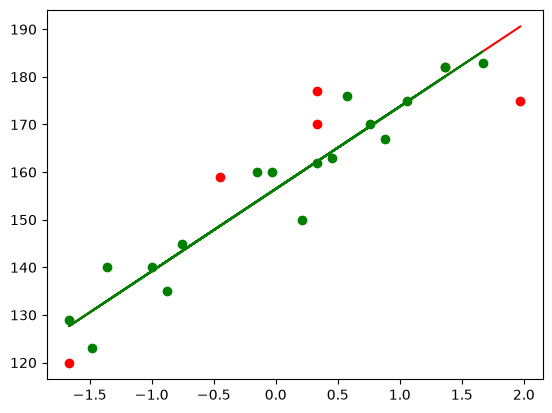

In [40]:
slr_plot=slr.predict(x_test_s)
plt.scatter(x_test_s,y_test,color='red')
plt.plot(x_test_s,slr_plot,color='red')
slr_plot_train=slr.predict(x_train_s)
plt.scatter(x_train_s,y_train,color='green')
plt.plot(x_train_s,slr_plot_train,color='green')


In [50]:
slr.predict(ss.transform([[84]]))

d:\Data Science\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([168.55254737])

In [53]:
#performance metrics
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
mse=mean_squared_error(y_test,slr_plot)
mae=mean_absolute_error(y_test,slr_plot)
r2=r2_score(y_test,slr_plot)
rmse=np.sqrt(mse)
absolute_r2=1-(1-r2)*(len(y_test)-1)/(len(y_test)-x_test_s.shape[1]-1)
print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("Root Mean Squared Error:", rmse)
print("R-squared Score:", r2)
print("Adjusted R-squared Score:", absolute_r2)

Mean Squared Error: 114.84069295228699
Mean Absolute Error: 9.66512588679501
Root Mean Squared Error: 10.716374991212605
R-squared Score: 0.7360826717981276
Adjusted R-squared Score: 0.6701033397476595
